<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/FedAvg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standard Federated Averaging (The Baseline)
## Establishing Control Metrics Across Data Modalities

**Objective:**
Before deploying advanced robust aggregation techniques (like Gradient Clipping or SCAFFOLD), we must establish a baseline. This notebook executes the standard Federated Averaging (FedAvg) algorithm—without any defensive filters or drift penalties.

To test the inherent structural robustness of different data types, the central server will inject **Statistical Noise (Gaussian and Laplace)** into the aggregated weights before broadcasting them back to the clients.

**Hypothesis:**
Without any advanced aggregation defenses, the network relies entirely on the natural resilience of the data.
1. **Dense Images (MNIST):** The geometric pixel structures will shatter under heavy-tailed Laplace noise, causing a catastrophic drop in accuracy.
2. **Scattered Tabular (Breast Cancer):** The independent, standardized features will naturally absorb the noise, maintaining high accuracy even without defensive algorithms like Clipping or FedProx.

### Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split, TensorDataset
import copy
import math
import matplotlib.pyplot as plt
import pandas as pd

### Architecture

In [2]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)

In [3]:
class TabularNet(nn.Module):
    def __init__(self):
        super(TabularNet, self).__init__()
        self.fc1 = nn.Linear(30, 16)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.fc3(x)

### Data Preparation

In [4]:
NUM_CLIENTS = 10

In [5]:
print("Preparing MNIST Dataset")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

mnist_full = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_split = random_split(mnist_full, [len(mnist_full) // NUM_CLIENTS] * NUM_CLIENTS)
mnist_loaders = [DataLoader(ds, batch_size=32, shuffle=True) for ds in mnist_split]

mnist_test = datasets.MNIST('./data', train=False, download=True, transform=transform)
mnist_test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

print("Data preparation complete")

Preparing MNIST Dataset


100%|██████████| 9.91M/9.91M [00:00<00:00, 22.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 605kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.78MB/s]

Data preparation complete


In [6]:
print("Preparing Breast Cancer Dataset (Strict Split)")

data = load_breast_cancer()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.data)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
tabular_train = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
tabular_test = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

tab_split_size = len(tabular_train) // NUM_CLIENTS
tab_splits = [tab_split_size] * NUM_CLIENTS
tab_splits[-1] += len(tabular_train) % NUM_CLIENTS
tabular_loaders = [DataLoader(ds, batch_size=8, shuffle=True) for ds in random_split(tabular_train, tab_splits)]
tabular_test_loader = DataLoader(tabular_test, batch_size=len(tabular_test), shuffle=False)

print("Data preparation complete")

Preparing Breast Cancer Dataset (Strict Split)
Data preparation complete


## Baseline Aggregation & Statistical Noise Injection

Here we define the standard `FedAvg` algorithm. Unlike our advanced defensive notebooks, this function applies **no speed limits (clipping)** and **no quantile filtering (Trimmed Mean)**. It simply averages whatever weights the clients provide.

After aggregation, the server injects Statistical Noise to test the structural resilience of the resulting model.

### Functions

In [7]:
def standard_fedavg_aggregation(client_weights_list):
    """Standard FedAvg: Simple mathematical average with zero defensive filtering."""
    avg_weights = copy.deepcopy(client_weights_list[0])
    for key in avg_weights.keys():
        stacked_weights = torch.stack([client[key] for client in client_weights_list])
        avg_weights[key] = torch.mean(stacked_weights, dim=0)
    return avg_weights

In [8]:
def add_statistical_noise(weights, noise_type='none', scale=0.05):
    """Injects statistical noise to test the structural robustness of the model."""
    if noise_type == 'none': return weights
    noisy_weights = copy.deepcopy(weights)
    for key in noisy_weights.keys():
        tensor = noisy_weights[key]
        if noise_type == 'normal':
            noise = torch.randn_like(tensor) * scale
        elif noise_type == 'laplace':
            m = torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([scale]))
            noise = m.sample(tensor.shape).squeeze(-1).to(tensor.device)
        noisy_weights[key] = tensor + noise
    return noisy_weights

### Evaluation

In [9]:
datasets_to_test = ['mnist', 'tabular']
noise_types_to_test = ['none', 'normal', 'laplace']
NOISE_SCALE = 0.05
federated_rounds = 5
epochs_per_round = 1

# Store final results for the table
experiment_results = {'mnist': {}, 'tabular': {}}

# Store per-round tracking (Added 'train_loss' and renamed 'loss' to 'test_loss')
history = {
    'mnist': {n: {'test_acc': [], 'test_loss': [], 'train_loss': []} for n in noise_types_to_test},
    'tabular': {n: {'test_acc': [], 'test_loss': [], 'train_loss': []} for n in noise_types_to_test}
}

criterion_eval = nn.CrossEntropyLoss()


for dataset in datasets_to_test:
    print(f"\nTESTING DATASET: {dataset.upper()}")

    for noise in noise_types_to_test:
        # 1. SETUP & RESET THE MODEL
        if dataset == 'mnist':
            global_model = MNISTNet()
            loaders = mnist_loaders
            test_loader = mnist_test_loader
            lr = 0.001
        else:
            global_model = TabularNet()
            loaders = tabular_loaders
            test_loader = tabular_test_loader
            lr = 0.01

        # 2. THE EXECUTION LOOP
        for round_num in range(federated_rounds):
            client_weights = []

            for client_idx in range(NUM_CLIENTS):
                local_model = MNISTNet() if dataset == 'mnist' else TabularNet()
                local_model.load_state_dict(global_model.state_dict())

                optimizer = optim.Adam(local_model.parameters(), lr=lr)
                criterion = nn.CrossEntropyLoss()

                local_model.train()
                for epoch in range(epochs_per_round):
                    for inputs, labels in loaders[client_idx]:
                        optimizer.zero_grad()
                        outputs = local_model(inputs)
                        loss = criterion(outputs, labels)
                        loss.backward()
                        optimizer.step()

                client_weights.append(local_model.state_dict())

            # Server Aggregation & Noise (Standard FedAvg)
            aggregated_weights = standard_fedavg_aggregation(client_weights)
            secured_weights = add_statistical_noise(aggregated_weights, noise_type=noise, scale=NOISE_SCALE)
            global_model.load_state_dict(secured_weights)

            # 3. ROUND EVALUATION (Train and Test)
            global_model.eval()

            # --- Evaluate on Training Data ---
            train_loss_accum = 0.0
            train_total = 0
            with torch.no_grad():
                for client_loader in loaders:
                    for inputs, labels in client_loader:
                        outputs = global_model(inputs)
                        train_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                        train_total += labels.size(0)
            avg_train_loss = train_loss_accum / train_total

            # --- Evaluate on Testing Data ---
            correct = 0
            test_total = 0
            test_loss_accum = 0.0
            with torch.no_grad():
                for inputs, labels in test_loader:
                    outputs = global_model(inputs)
                    test_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    test_total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            acc = 100 * correct / test_total
            avg_test_loss = test_loss_accum / test_total

            # Store metrics
            history[dataset][noise]['test_acc'].append(acc)
            history[dataset][noise]['test_loss'].append(avg_test_loss)
            history[dataset][noise]['train_loss'].append(avg_train_loss)

        # 4. FINAL OUTPUT PER CONFIGURATION
        final_accuracy = history[dataset][noise]['test_acc'][-1]
        print(f"[{noise.upper()}] Final Accuracy: {final_accuracy:.3f}%")
        experiment_results[dataset][noise] = round(final_accuracy, 3)


TESTING DATASET: MNIST
[NONE] Final Accuracy: 94.640%
[NORMAL] Final Accuracy: 86.890%
[LAPLACE] Final Accuracy: 66.650%

TESTING DATASET: TABULAR
[NONE] Final Accuracy: 99.123%
[NORMAL] Final Accuracy: 98.246%
[LAPLACE] Final Accuracy: 96.491%


In [10]:
print("\n" + "="*50)
print(" STANDARD FEDAVG RESULTS")
print("="*50)

results_df = pd.DataFrame(experiment_results).T
results_df.columns = ['Baseline (No Noise)', 'Normal (Gaussian)', 'Laplace']
results_df.index = ['MNIST (Dense)', 'Breast Cancer (Scattered)']
print(results_df.to_string())
print("="*50)


 STANDARD FEDAVG RESULTS
                           Baseline (No Noise)  Normal (Gaussian)  Laplace
MNIST (Dense)                           94.640             86.890   66.650
Breast Cancer (Scattered)               99.123             98.246   96.491


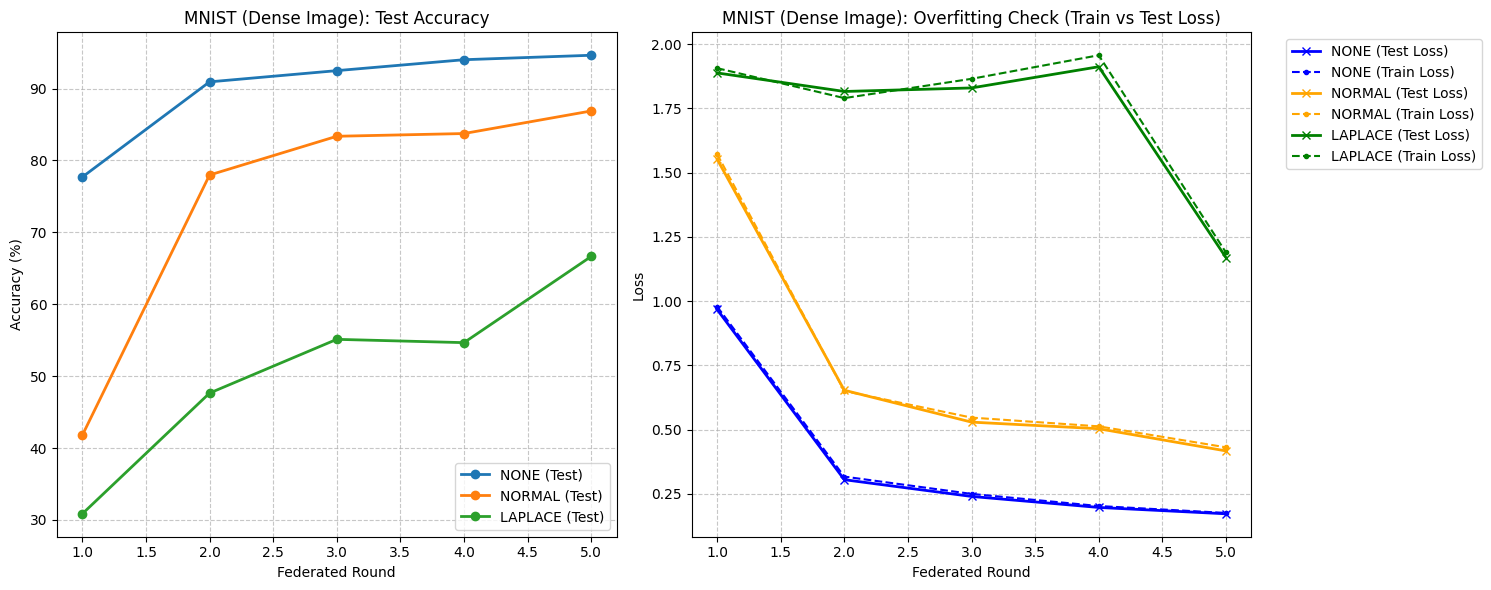

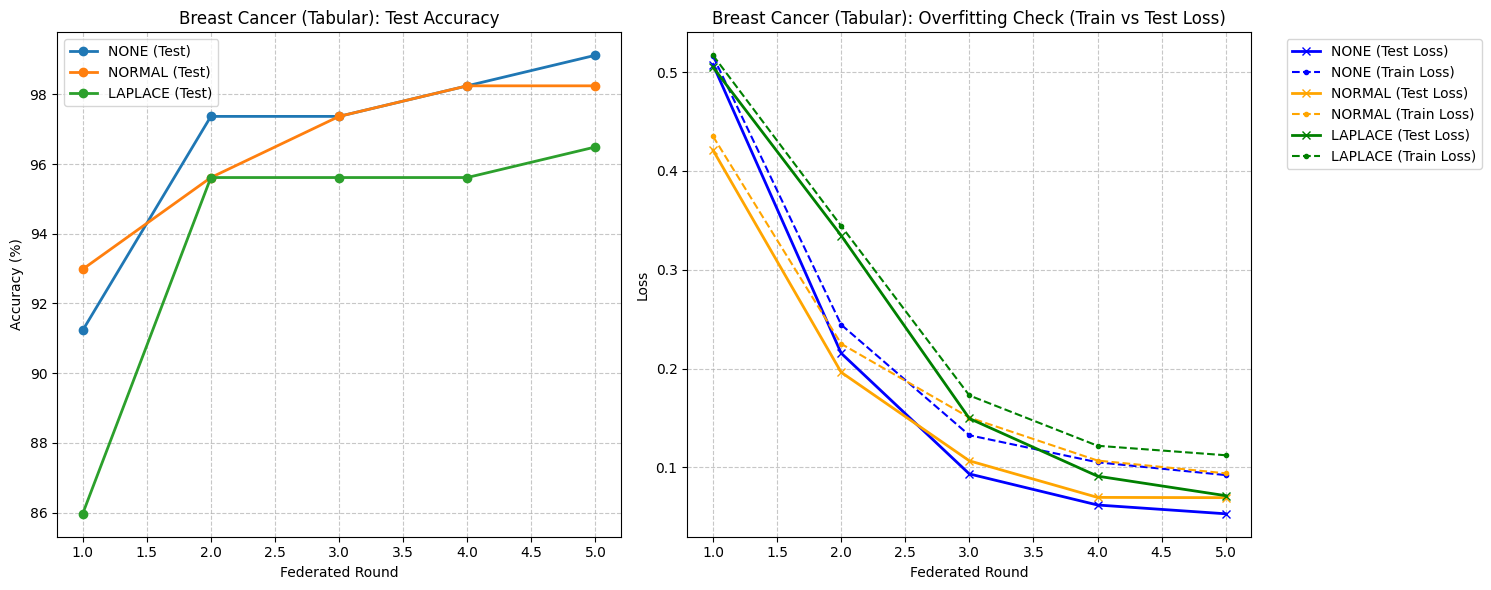

In [11]:
for dataset in datasets_to_test:
    dataset_name = "MNIST (Dense Image)" if dataset == 'mnist' else "Breast Cancer (Tabular)"

    plt.figure(figsize=(15, 6))

    # --- Subplot 1: Test Accuracy ---
    plt.subplot(1, 2, 1)
    for noise in noise_types_to_test:
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['test_acc'], marker='o', linewidth=2, label=f"{noise.upper()} (Test)")
    plt.title(f'{dataset_name}: Test Accuracy')
    plt.xlabel('Federated Round')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # --- Subplot 2: Train vs Test Loss (Overfitting Check) ---
    plt.subplot(1, 2, 2)
    colors = {'none': 'blue', 'normal': 'orange', 'laplace': 'green'}

    for noise in noise_types_to_test:
        c = colors[noise]
        # Plot Test Loss (Solid Line)
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['test_loss'], marker='x', linestyle='-', linewidth=2, color=c, label=f"{noise.upper()} (Test Loss)")
        # Plot Train Loss (Dashed Line)
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['train_loss'], marker='.', linestyle='--', linewidth=1.5, color=c, label=f"{noise.upper()} (Train Loss)")

    plt.title(f'{dataset_name}: Overfitting Check (Train vs Test Loss)')
    plt.xlabel('Federated Round')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    # Move legend outside the plot so it doesn't cover the lines
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

## Final Observations: Standard FedAvg Baseline & Overfitting Check

The execution of the standard FedAvg pipeline yielded two critical verifications for our experimental framework:

**1. Verification of Generalization (No Overfitting)**
By tracking both the Training Loss and Testing Loss per round, we confirmed that our network architectures are correctly sized. Across both modalities, the Training and Testing loss curves remained tightly coupled, decreasing in tandem without diverging. This proves that the networks are genuinely generalizing the data rather than memorizing the training sets.

**2. Baseline Modality Robustness**
The final accuracy metrics perfectly illustrate the inherent structural differences between data types when subjected to statistical noise:
* **Dense Images (MNIST):** Displayed extreme fragility. While the baseline converged to a strong 94.64%, the injection of heavy-tailed Laplace noise shattered the spatial pixel relationships, plummeting accuracy to 66.65%.
* **Scattered Tabular (Breast Cancer):** Displayed inherent resilience. The baseline achieved 99.12%, and the Laplace noise barely registered an impact, maintaining an exceptional 96.49%.

**Conclusion:** These metrics serve as our definitive control group. They prove that while tabular data naturally resists statistical perturbation, image networks absolutely require advanced defensive aggregation to maintain utility under privacy-preserving conditions.